In [14]:
import pandas as pd

# Your master panel (GDP + Attacks)
df_master = df_gdp_attacks_panel.copy()

# List of other datasets to merge
panel_datasets = [
    df_population_panel,
    df_poverty_panel,
    df_school_panel,
    df_unemployment,
    df_inequality_panel
]

# Step: Merge all datasets with suffixes to avoid column overlap
for i, df in enumerate(panel_datasets, start=1):
    # Add suffix based on dataset number or name
    suffix = f"_ds{i}"  # or use a descriptive name like "_pop", "_poverty"
    
    # Merge with suffix
    df_master = df_master.join(df, how='left', rsuffix=suffix)

# Optional: check merged panel
print("Master panel shape:", df_master.shape)
print("\nColumns in master panel:\n", df_master.columns)

# Step: Save to CSV
df_master.to_csv(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Final_Master_Panel_AllColumns.csv")

print("Master panel with all columns saved successfully!")


Master panel shape: (12066, 8)

Columns in master panel:
 Index(['Country Code', 'GDP', 'Attacks', 'Total_Population',
       'Poverty_Headcount', 'Secondary_Enrollment', 'Unemployment_Rate',
       'Inequality_Measure'],
      dtype='object')
Master panel with all columns saved successfully!


In [16]:
import pandas as pd

# ==========================
# Load WGI master panel
# ==========================
wgi = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\WGI_master_panel.xlsx"
)
wgi.columns = wgi.columns.str.strip()
wgi["Country"] = wgi["Country"].str.strip().str.lower()

# ==========================
# Load terrorism data
# ==========================
attacks = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Terror.xlsx",
    sheet_name="Terror_Long_1970_2020"
)
attacks.columns = attacks.columns.str.strip()

# Standardize country name
attacks["Country"] = attacks["Country"].str.strip().str.lower()

# Convert attacks to numeric
attacks["Attacks"] = pd.to_numeric(attacks["Attacks"], errors="coerce")

# ==========================
# Drop redundant column
# ==========================
if "COUNTRIES" in attacks.columns:
    attacks = attacks.drop(columns=["COUNTRIES"])

# ==========================
# Safety check: one row per Country–Year
# ==========================
dup = attacks.duplicated(subset=["Country", "Year"]).sum()
print("Duplicate Country–Year rows in attacks:", dup)

# If duplicates exist, collapse (defensive)
if dup > 0:
    attacks = (
        attacks
        .groupby(["Country", "Year"], as_index=False)["Attacks"]
        .sum()
    )

# ==========================
# Merge with WGI panel
# ==========================
final_panel = wgi.merge(
    attacks,
    on=["Country", "Year"],
    how="left",
    validate="one_to_one"
)

# ==========================
# Final checks
# ==========================
print("Final panel shape:", final_panel.shape)
print("Countries:", final_panel["Country"].nunique())
print("Years:", final_panel["Year"].min(), "-", final_panel["Year"].max())
print(
    "Duplicate Country–Year rows after merge:",
    final_panel.duplicated(subset=["Country", "Year"]).sum()
)


Duplicate Country–Year rows in attacks: 0
Final panel shape: (3902, 9)
Countries: 166
Years: 1996 - 2024
Duplicate Country–Year rows after merge: 0


In [17]:
print(final_panel.head(10))


       Country  Year  Control of corruption  Rule of law  \
0  afghanistan  2004                    0.0        0.075   
1  afghanistan  2005                    0.0        0.075   
2  afghanistan  2006                    0.0        0.025   
3  afghanistan  2007                    NaN          NaN   
4  afghanistan  2008                    NaN          NaN   
5  afghanistan  2009                    0.0        0.075   
6  afghanistan  2010                    0.0        0.075   
7  afghanistan  2011                    0.0        0.075   
8  afghanistan  2012                    0.0        0.075   
9  afghanistan  2013                    0.0        0.075   

   Government Effectiveness  Political Stability  Voice and Accountability  \
0                      0.25               0.1875                  0.000000   
1                      0.25               0.0625                  0.000000   
2                      0.00               0.0625                  0.102000   
3                       NaN

In [19]:
output_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\WGI_master_panel_final.xlsx"

final_panel.to_excel(
    output_path,
    sheet_name="WGI_Master_Panel",
    index=False
)

print(f"WGI master panel saved successfully at:\n{output_path}")


WGI master panel saved successfully at:
C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\WGI_master_panel_final.xlsx


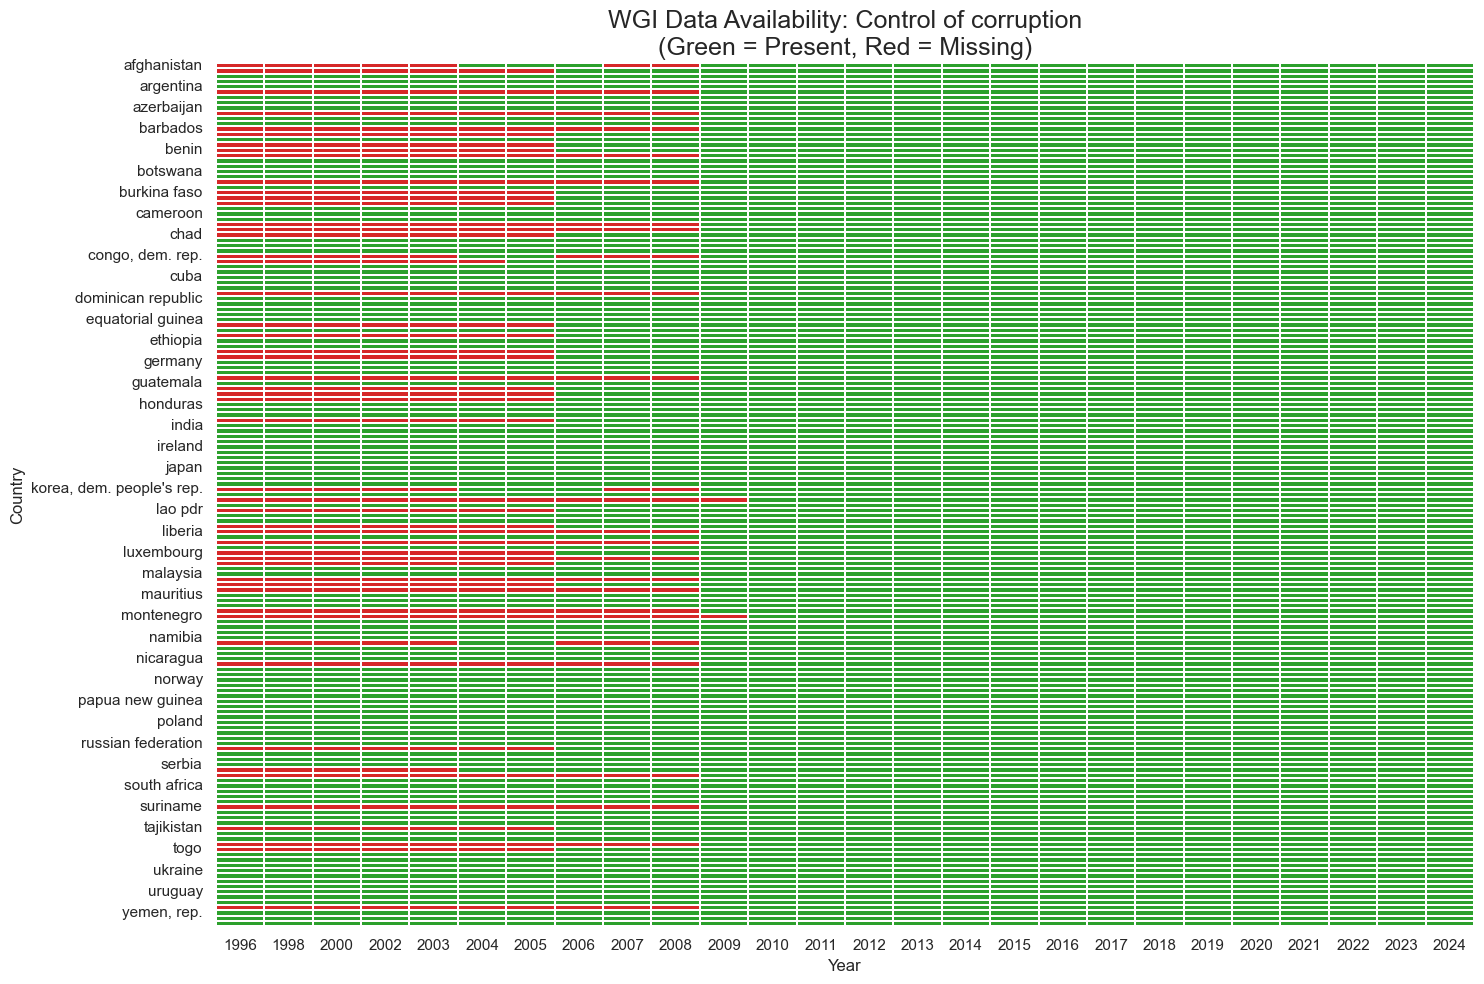

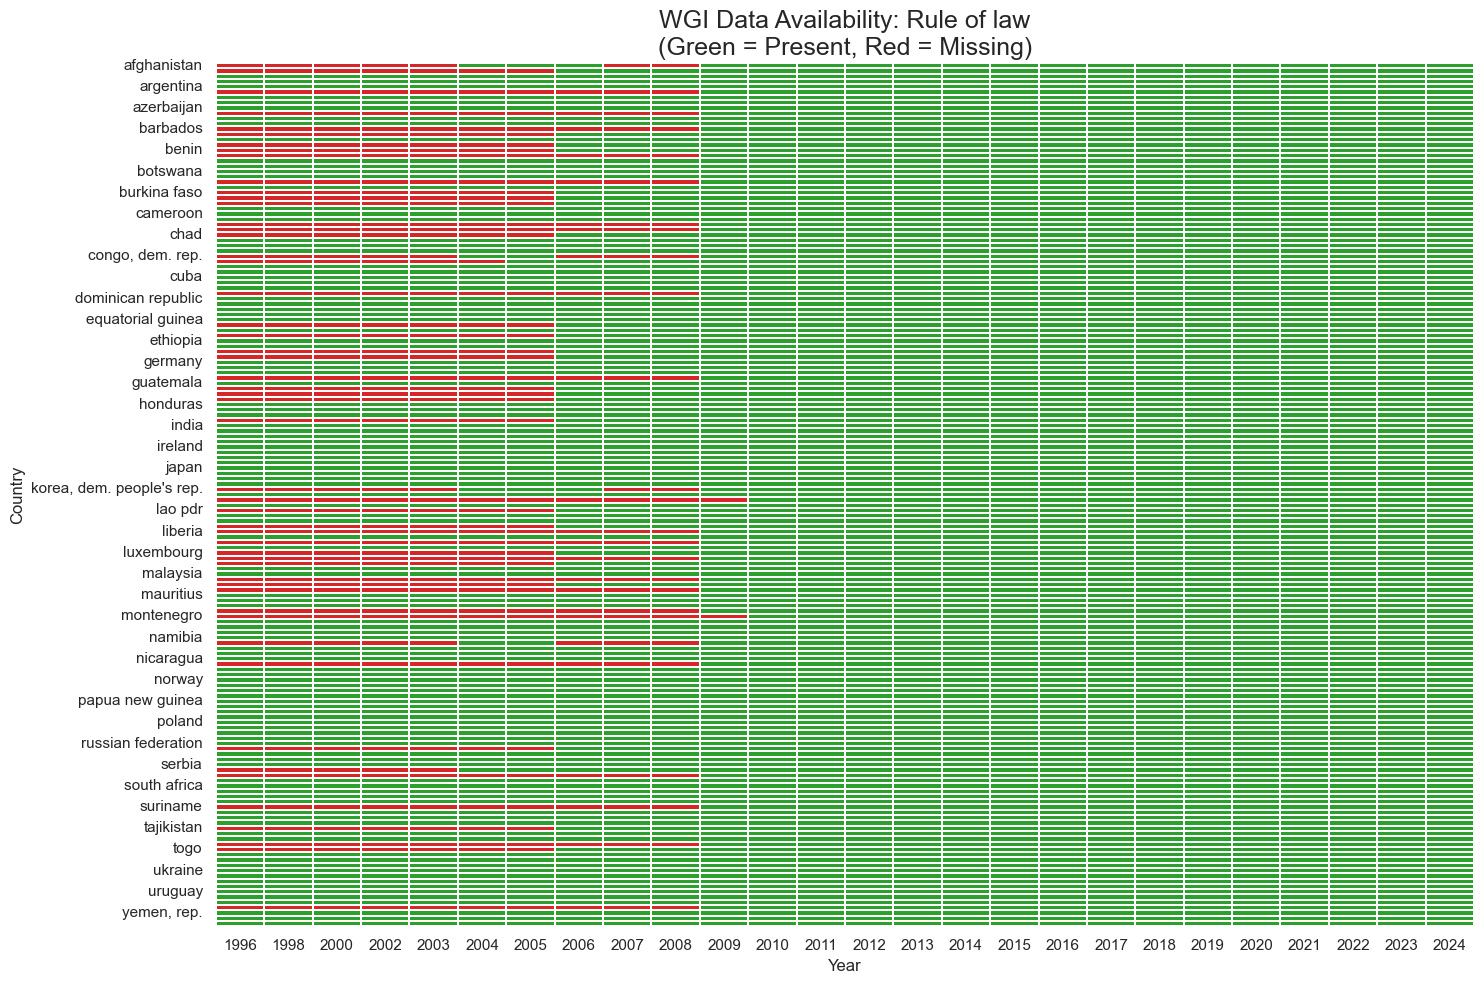

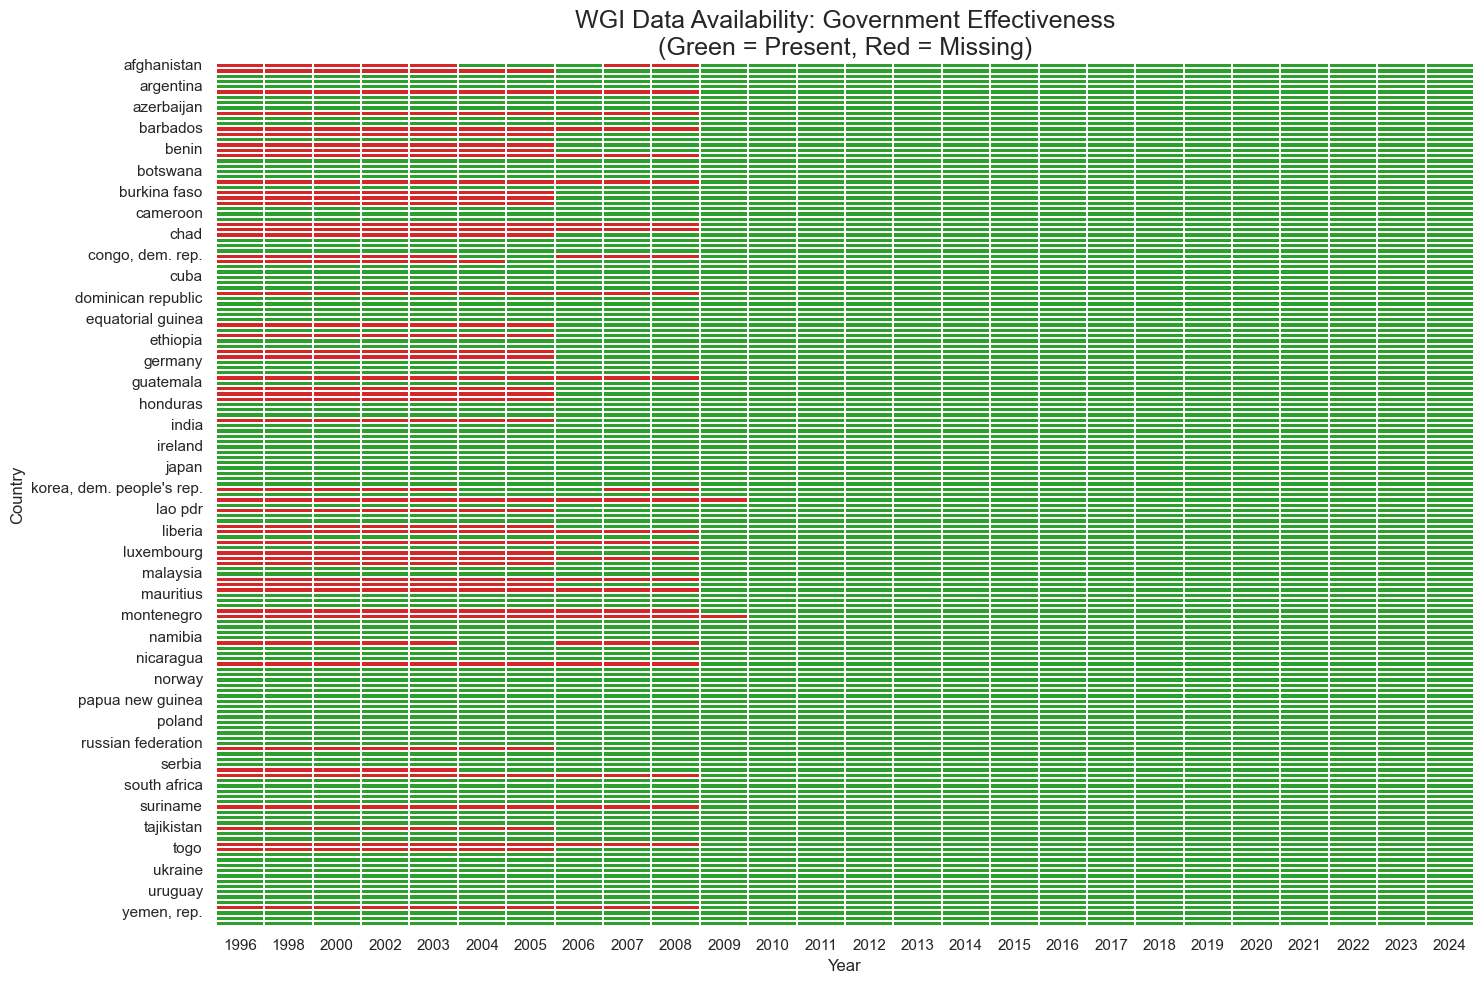

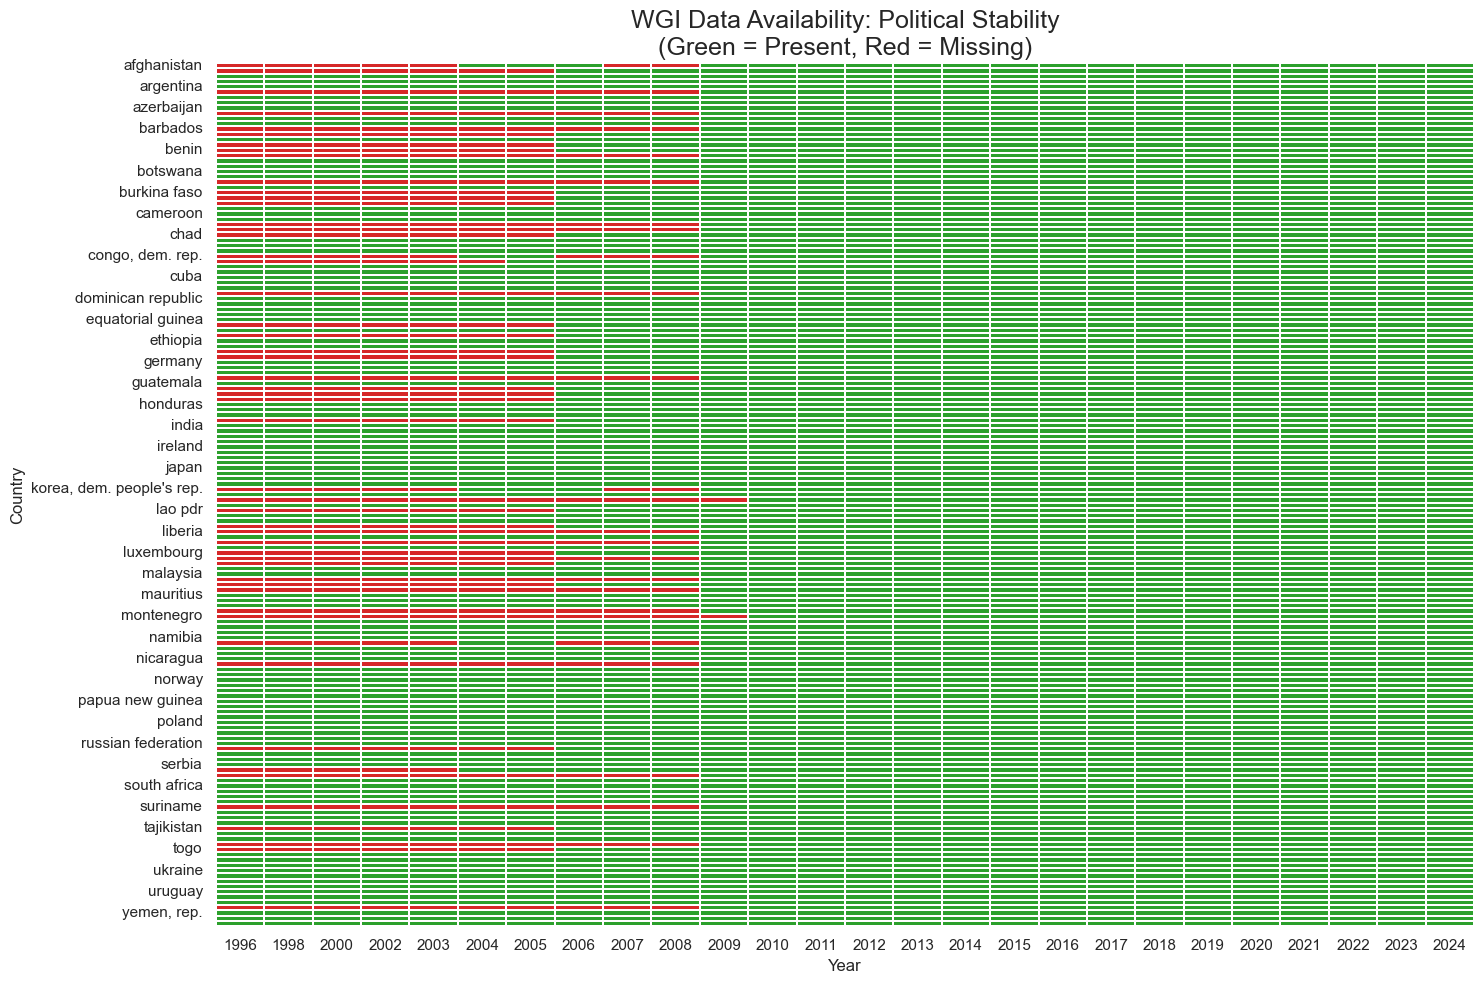

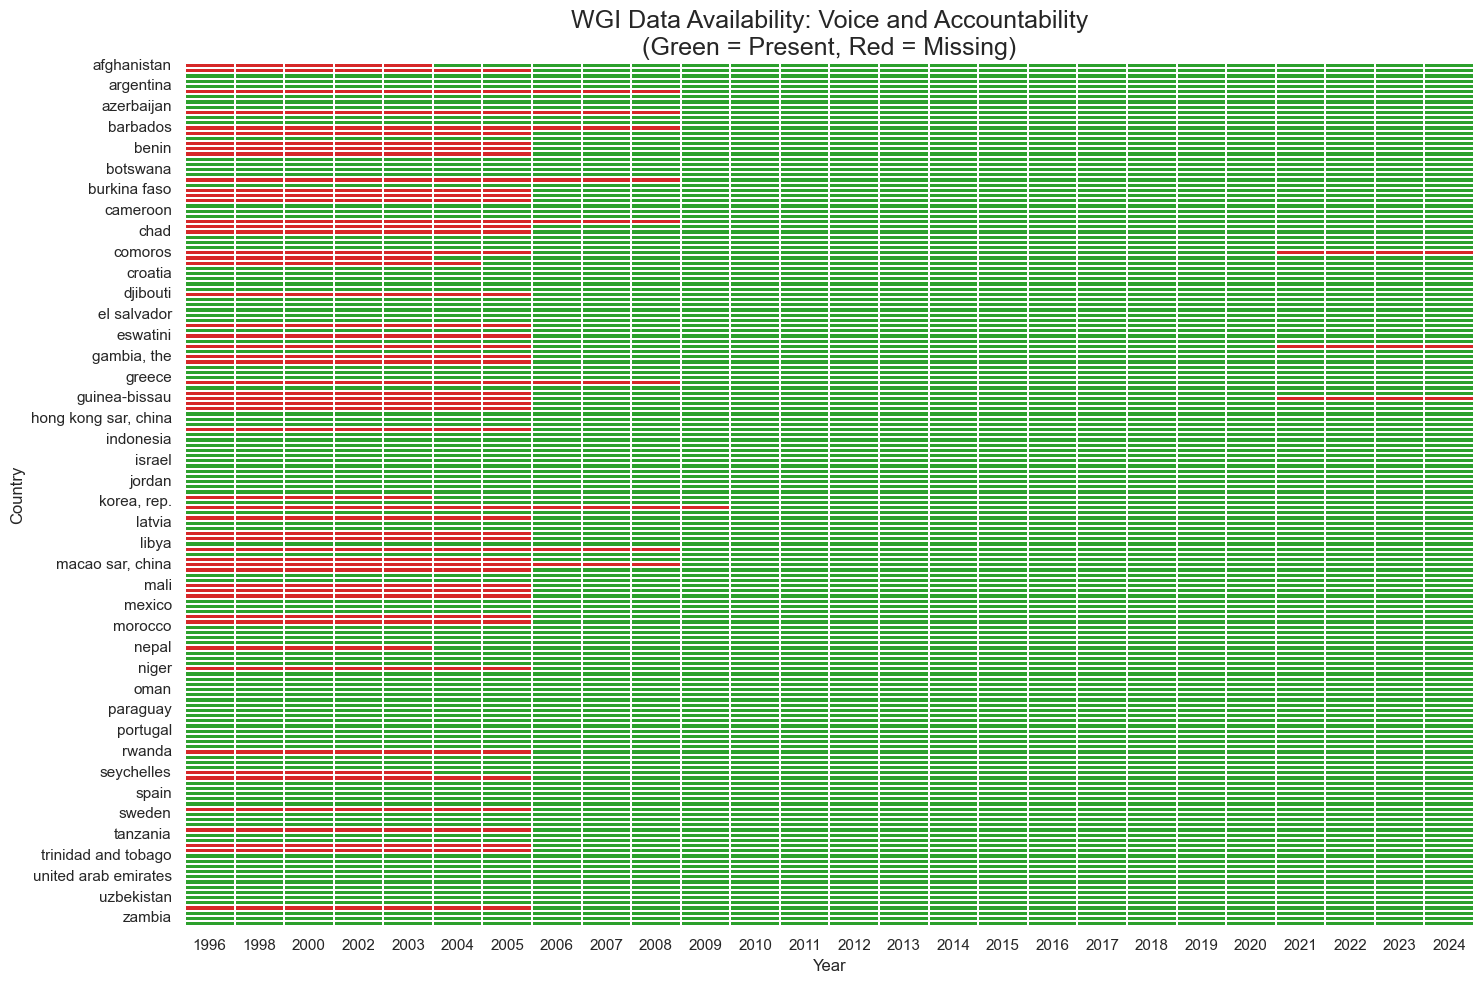

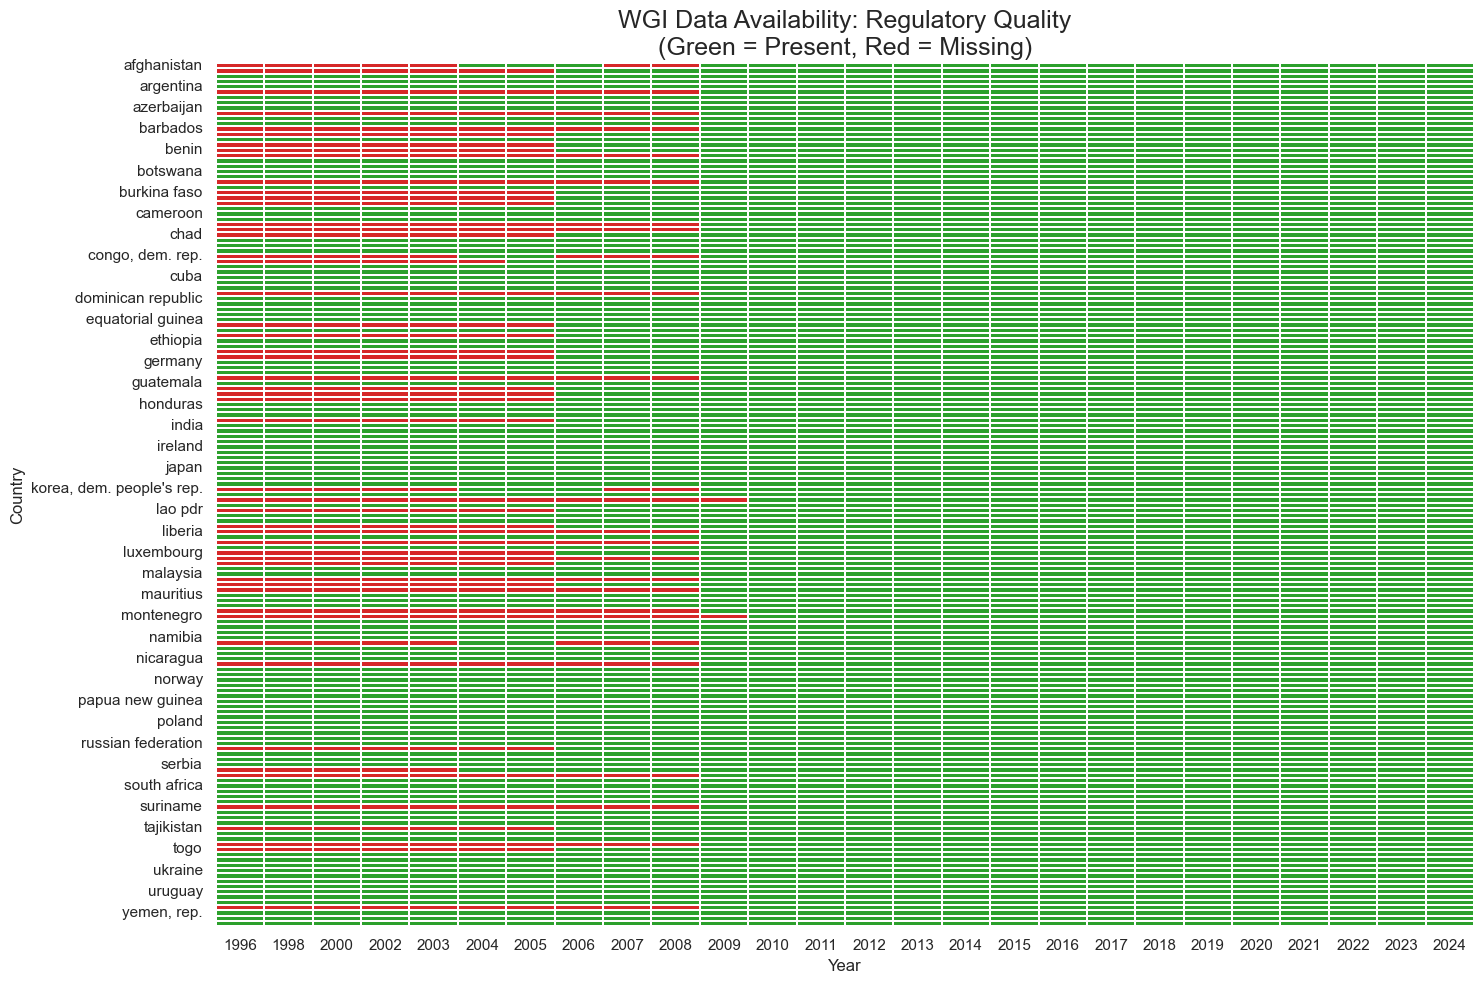

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Load WGI master panel
# ==========================
df = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\WGI_master_panel_final.xlsx"
)

df.columns = df.columns.str.strip()

# ==========================
# WGI indicator columns
# ==========================
wgi_cols = [
    "Control of corruption",
    "Rule of law",
    "Government Effectiveness",
    "Political Stability",
    "Voice and Accountability",
    "Regulatory Quality"
]

# Ensure numeric
for col in wgi_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

sns.set_theme(style="white")

# ==========================
# Availability heatmaps
# ==========================
for col in wgi_cols:

    # Pivot to Country × Year matrix
    pivot_df = df.pivot_table(
        index="Country",
        columns="Year",
        values=col,
        aggfunc="mean"   # safe against duplicates
    )

    # Presence mask: 1 = available, 0 = missing
    presence_mask = pivot_df.notna().astype(int)

    plt.figure(figsize=(15, 10))
    sns.heatmap(
        presence_mask,
        cmap=["#d62728", "#2ca02c"],  # red = missing, green = present
        cbar=False,
        linewidths=0.3
    )

    plt.title(
        f"WGI Data Availability: {col}\n(Green = Present, Red = Missing)",
        fontsize=18
    )
    plt.xlabel("Year")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()


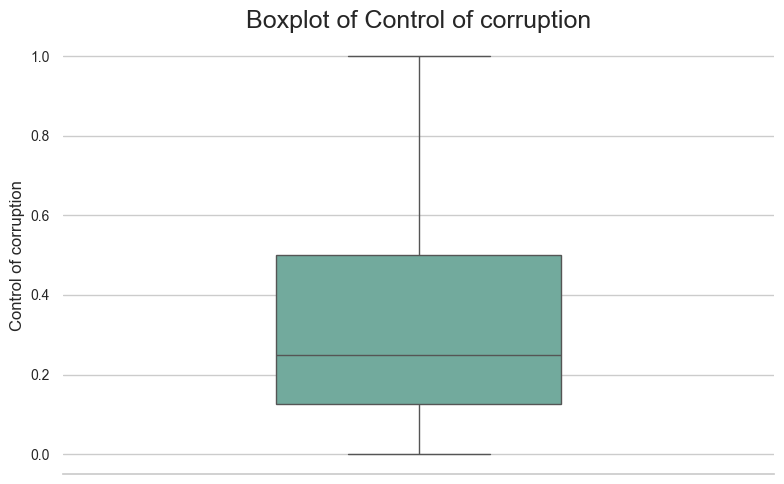

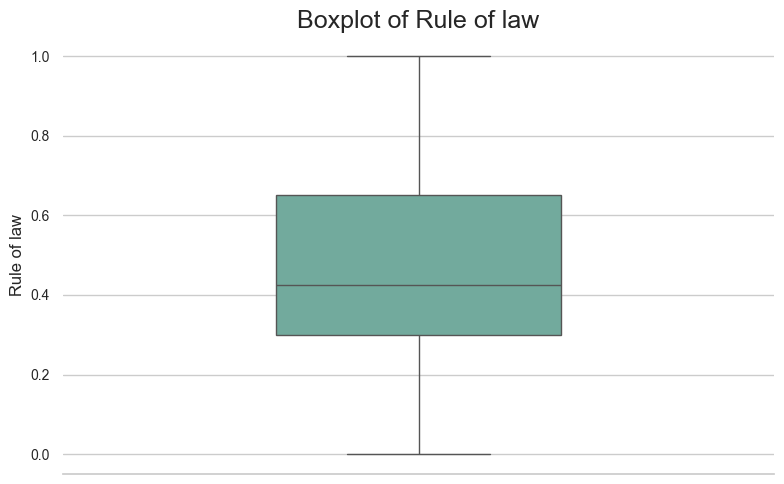

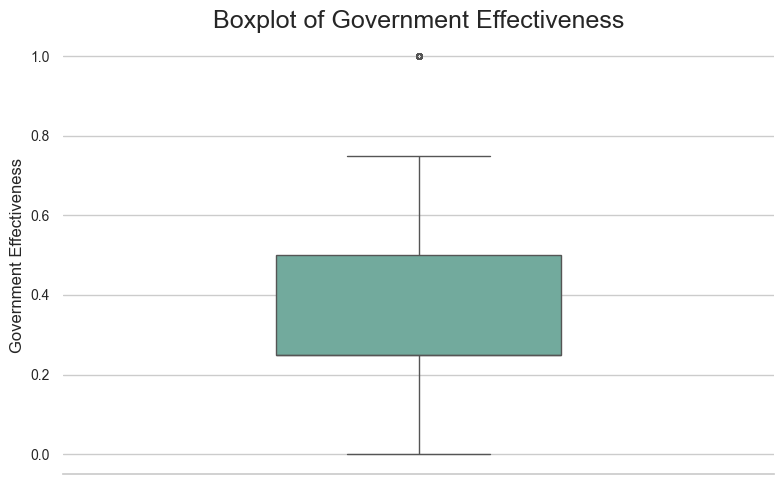

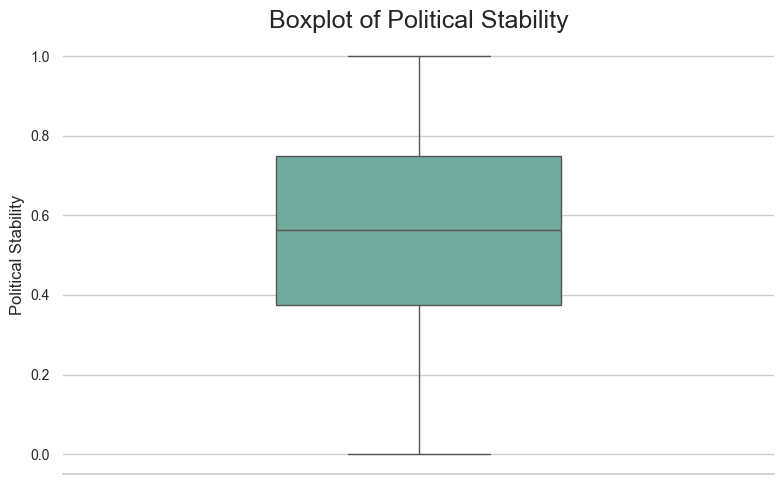

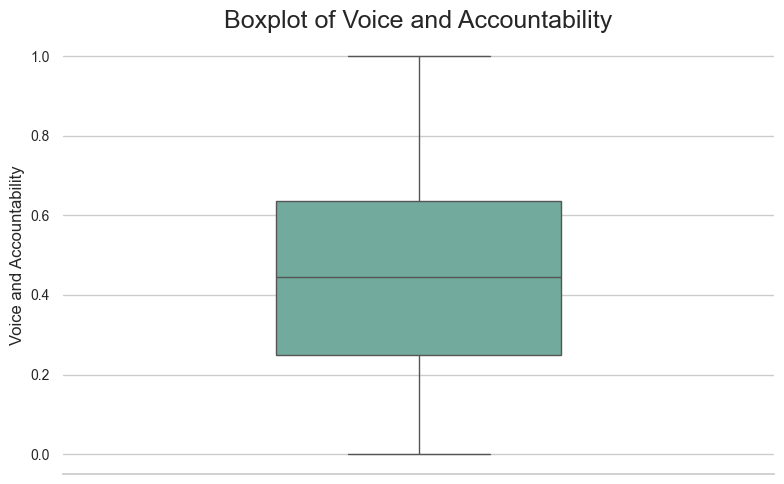

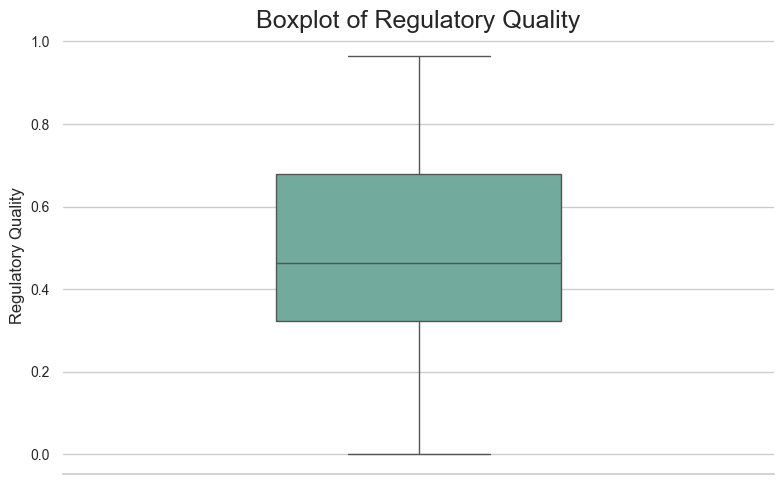

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Load WGI master panel
# ==========================
df = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\WGI_master_panel_final.xlsx"
)
df.columns = df.columns.str.strip()

# ==========================
# WGI indicators
# ==========================
wgi_cols = [
    "Control of corruption",
    "Rule of law",
    "Government Effectiveness",
    "Political Stability",
    "Voice and Accountability",
    "Regulatory Quality"
]

# Convert to numeric
for col in wgi_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================
# Aesthetic settings (same as yours)
# ==========================
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# ==========================
# Boxplots
# ==========================
for col in wgi_cols:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        y=df[col],
        color="#69b3a2",
        width=0.4,
        fliersize=4
    )

    plt.title(f"Boxplot of {col}", fontsize=18)
    plt.ylabel(col)
    plt.xlabel("")
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()


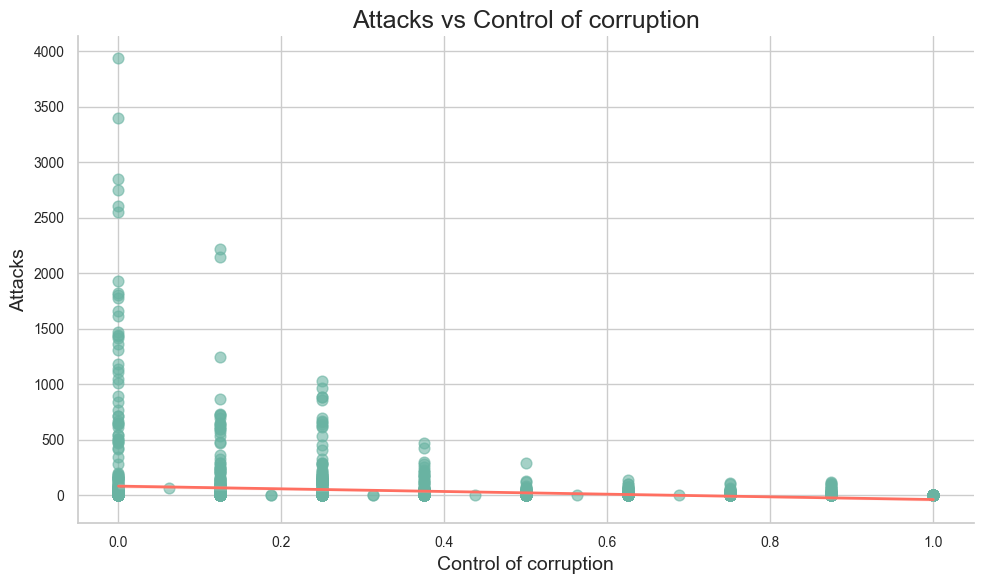

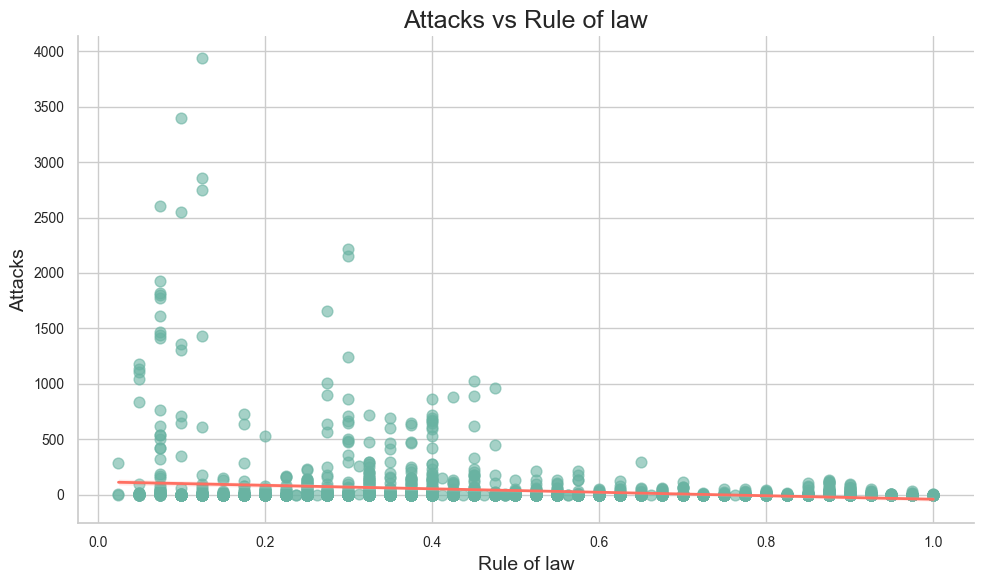

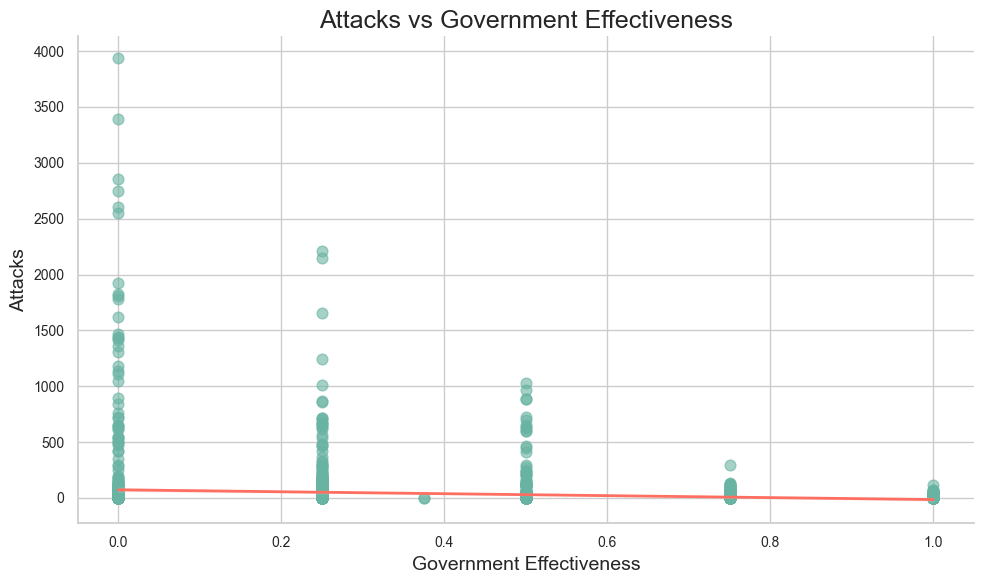

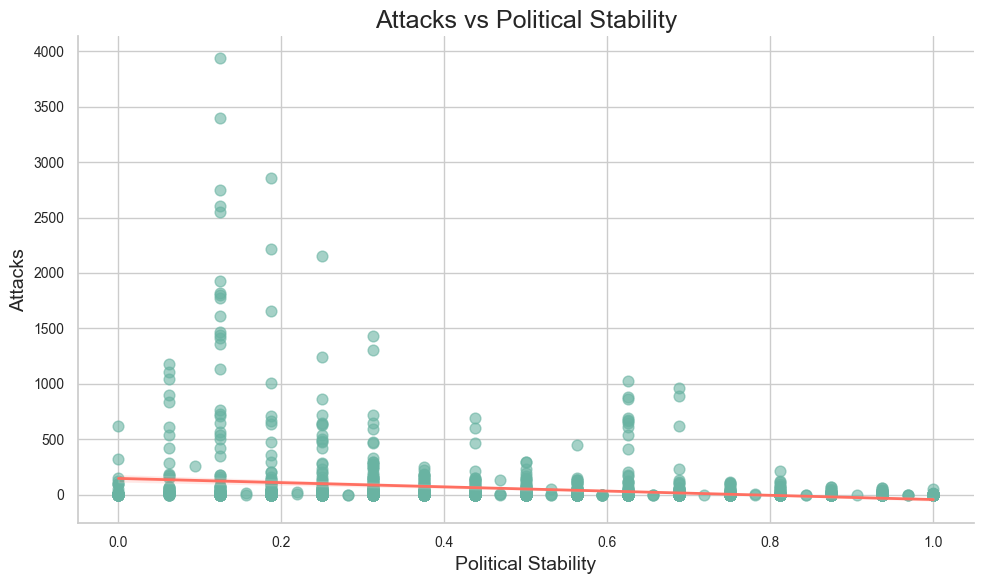

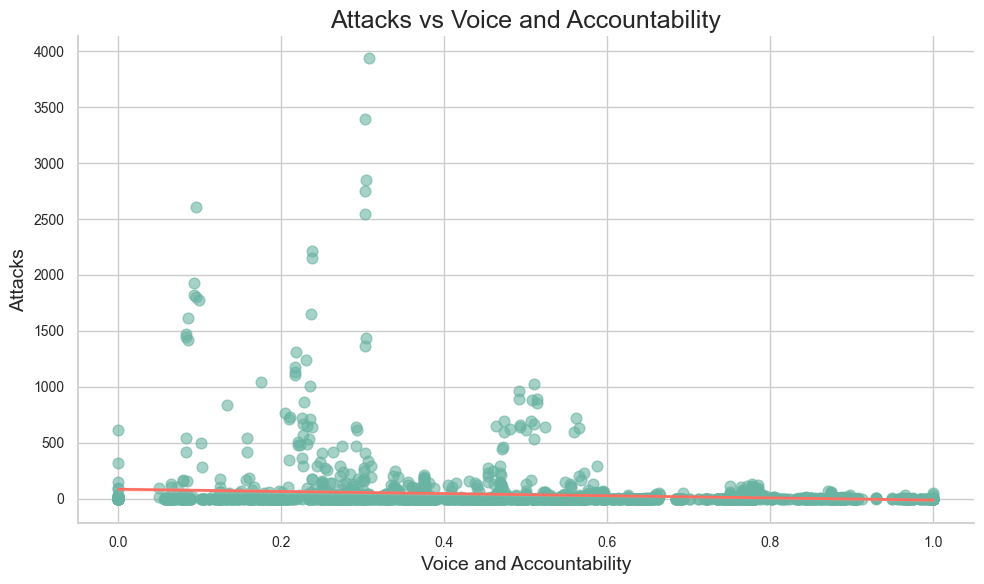

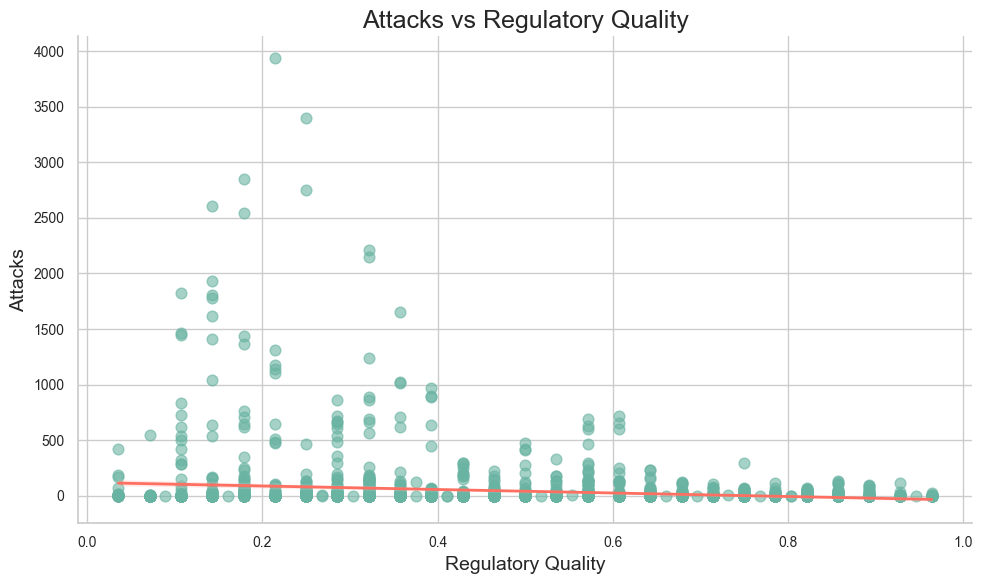

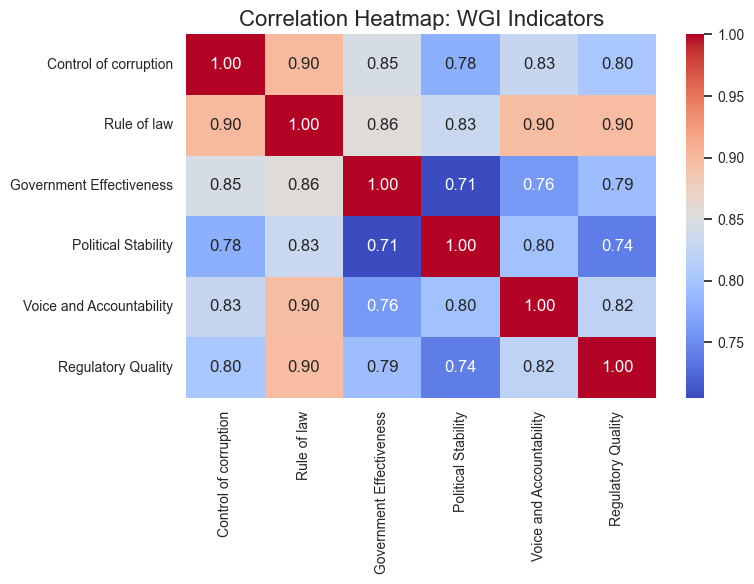

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Load merged master panel
# ==========================
df = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\WGI_master_panel_final.xlsx"
)
df.columns = df.columns.str.strip()

# ==========================
# WGI indicators
# ==========================
wgi_cols = [
    "Control of corruption",
    "Rule of law",
    "Government Effectiveness",
    "Political Stability",
    "Voice and Accountability",
    "Regulatory Quality"
]

# Convert to numeric
for col in wgi_cols + ["Attacks"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================
# Aesthetic settings
# ==========================
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# ==========================
# Scatterplots with regression line
# ==========================
for col in wgi_cols:
    plt.figure(figsize=(10, 6))

    sns.regplot(
        x=col,
        y="Attacks",
        data=df,
        scatter_kws={
            "alpha": 0.6,
            "s": 60,
            "color": "#69b3a2"
        },
        line_kws={
            "color": "#ff6f61",
            "lw": 2
        }
    )

    plt.title(f"Attacks vs {col}", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("Attacks", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

# ==========================
# Correlation heatmap (WGI only)
# ==========================
plt.figure(figsize=(8, 6))
corr = df[wgi_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True
)

plt.title("Correlation Heatmap: WGI Indicators", fontsize=16)
plt.tight_layout()
plt.show()


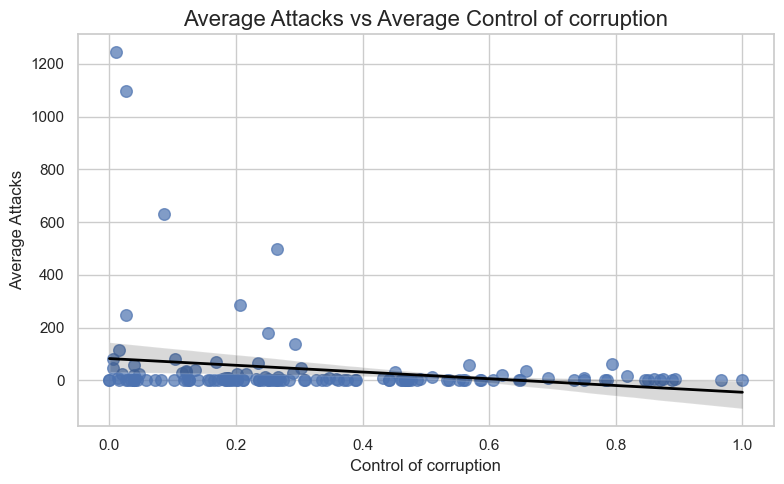

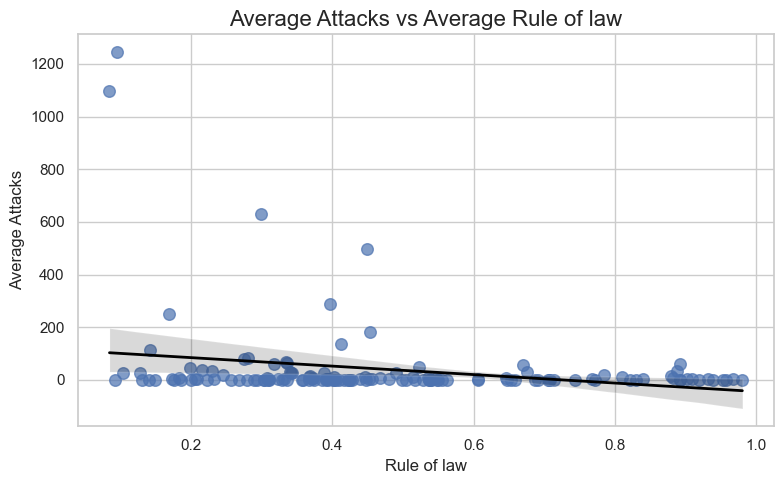

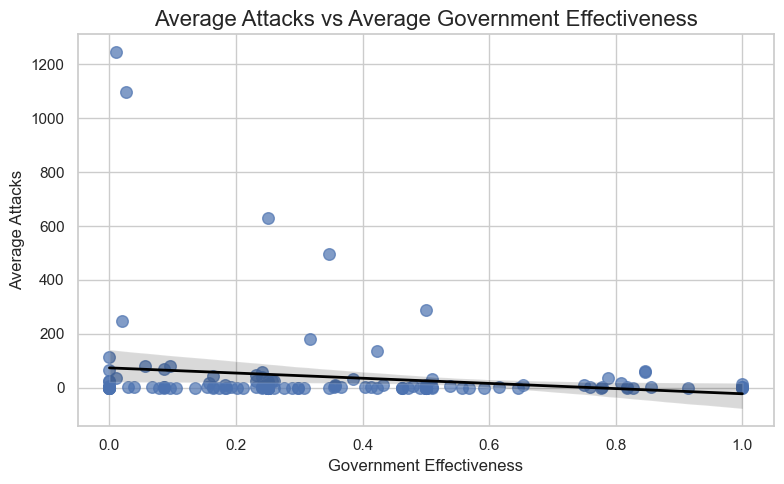

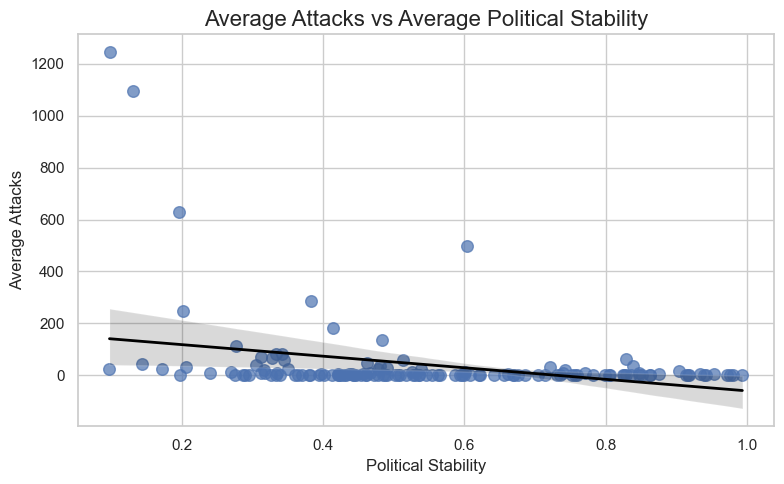

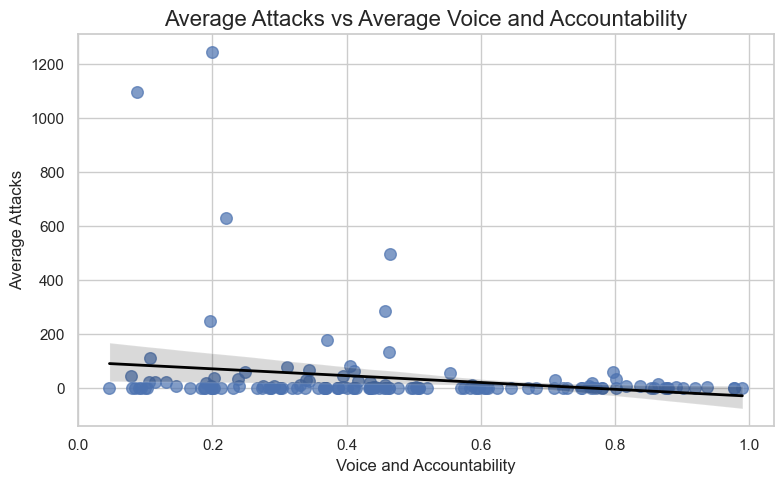

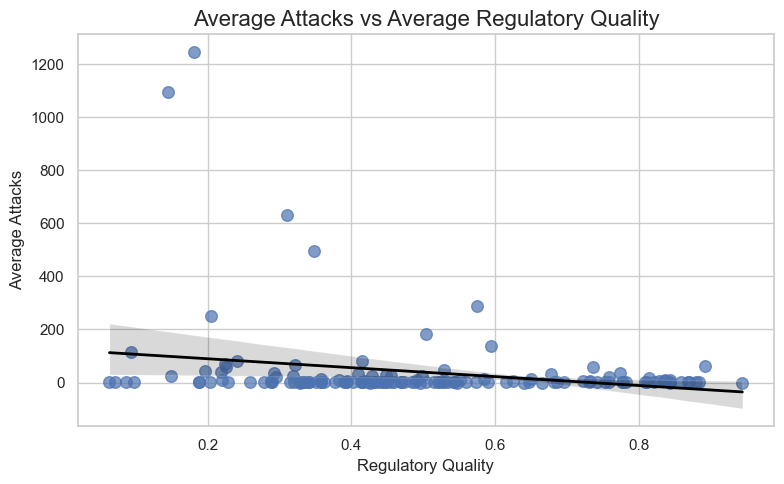

In [28]:
# ==========================
# Country-averaged relationship
# ==========================
df_avg = (
    df
    .groupby("Country")[wgi_cols + ["Attacks"]]
    .mean()
    .reset_index()
)

for col in wgi_cols:

    plt.figure(figsize=(8, 5))
    sns.regplot(
        x=col,
        y="Attacks",
        data=df_avg,
        scatter_kws={"alpha": 0.7, "s": 70},
        line_kws={"color": "black", "lw": 2}
    )

    plt.title(f"Average Attacks vs Average {col}")
    plt.xlabel(col)
    plt.ylabel("Average Attacks")
    plt.tight_layout()
    plt.show()


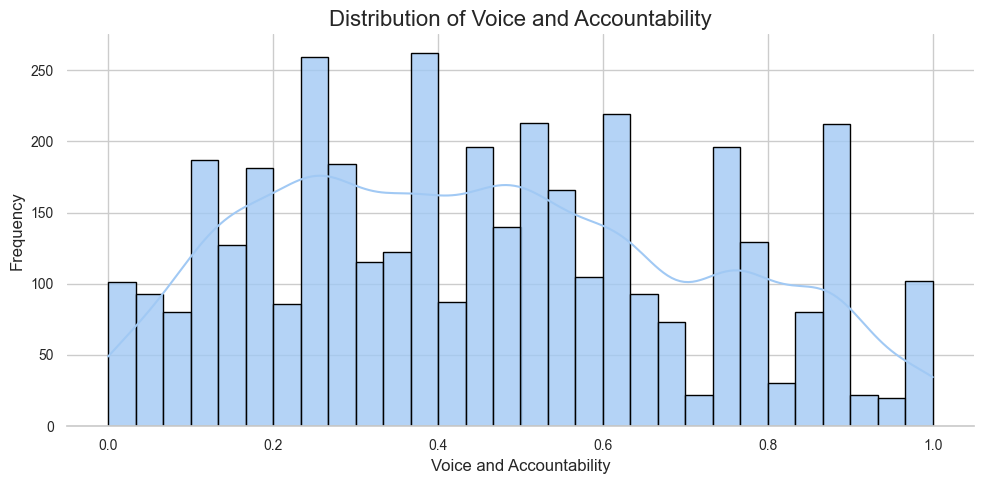

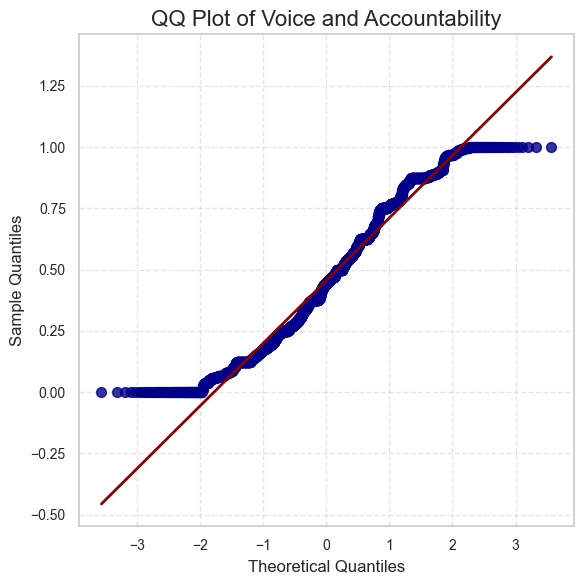

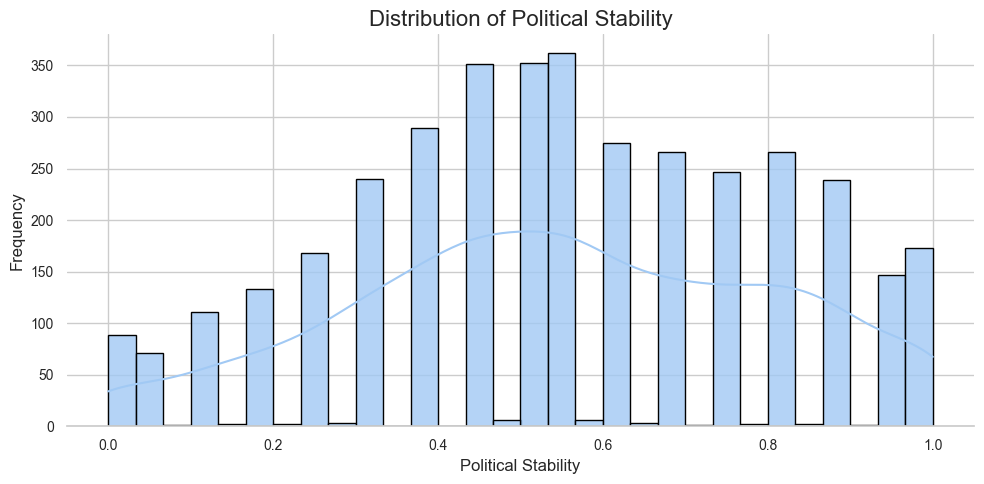

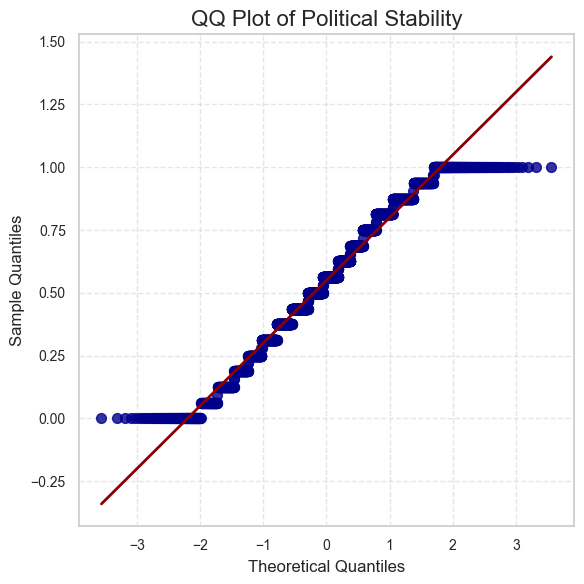

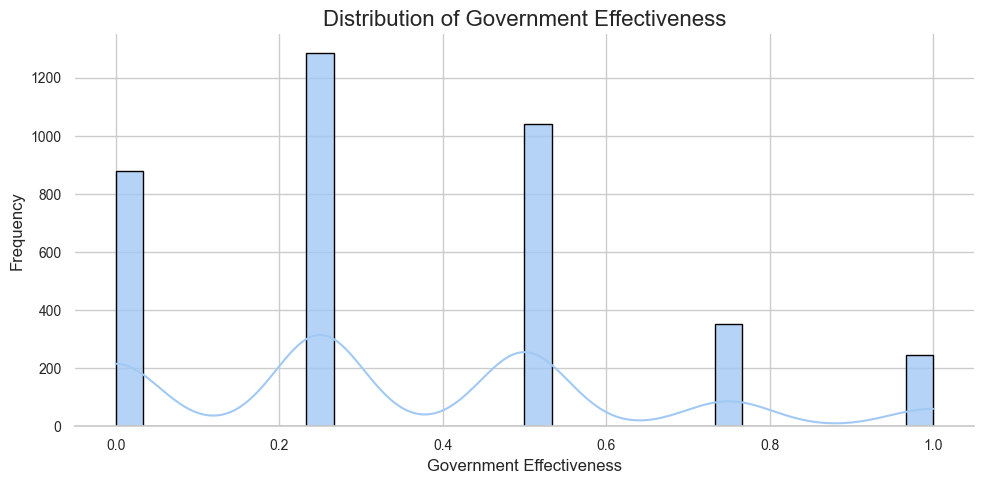

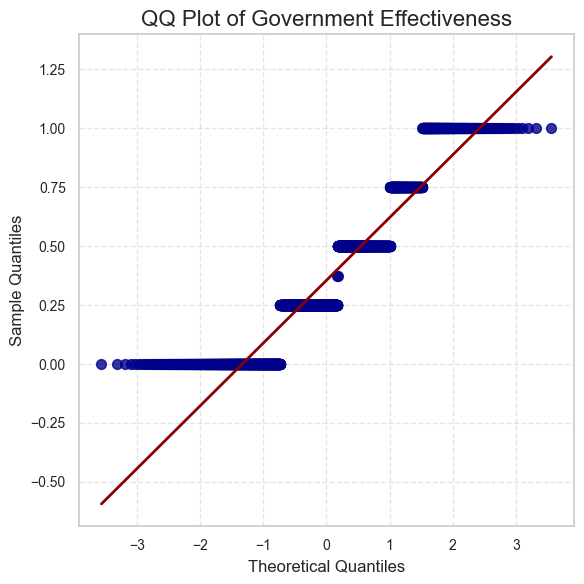

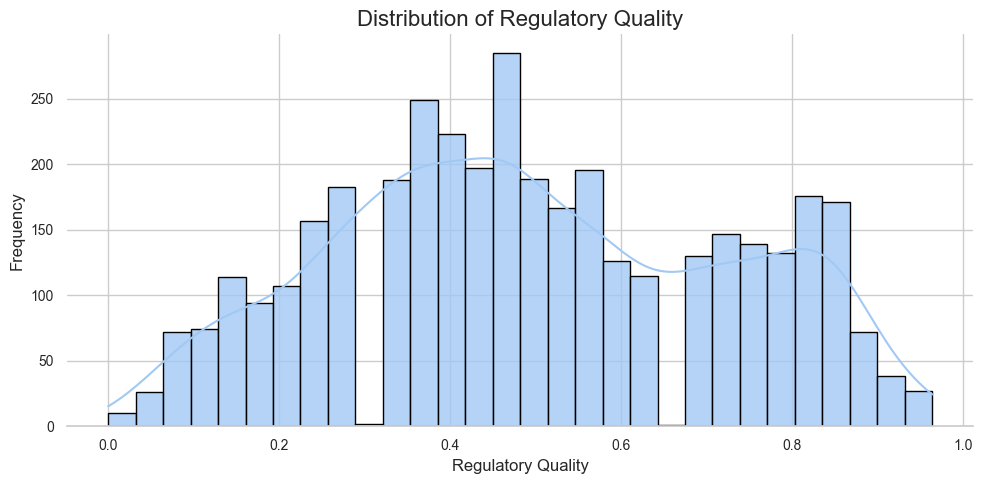

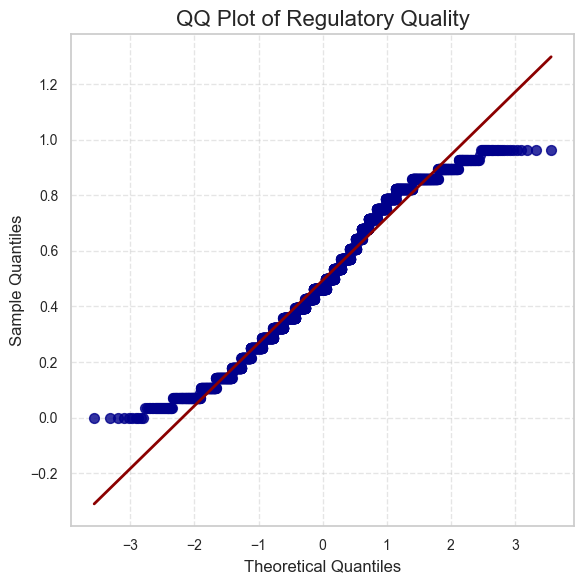

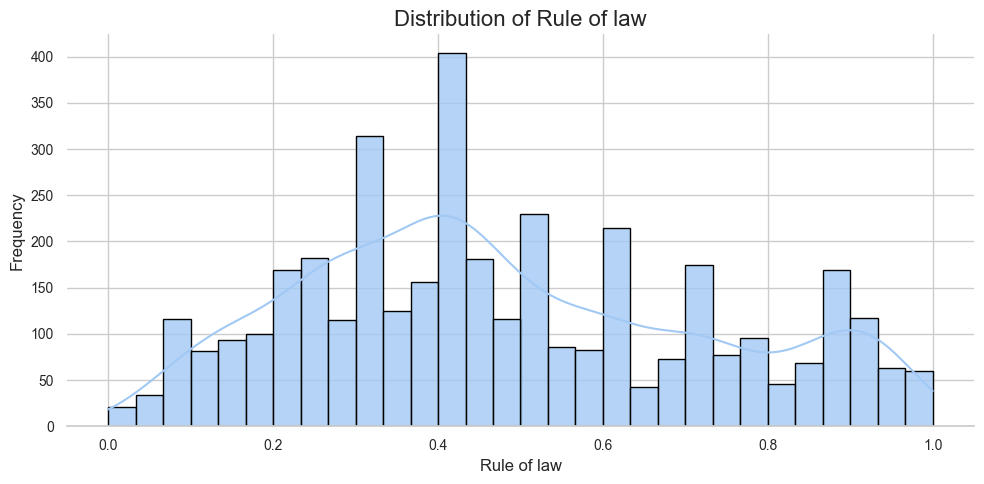

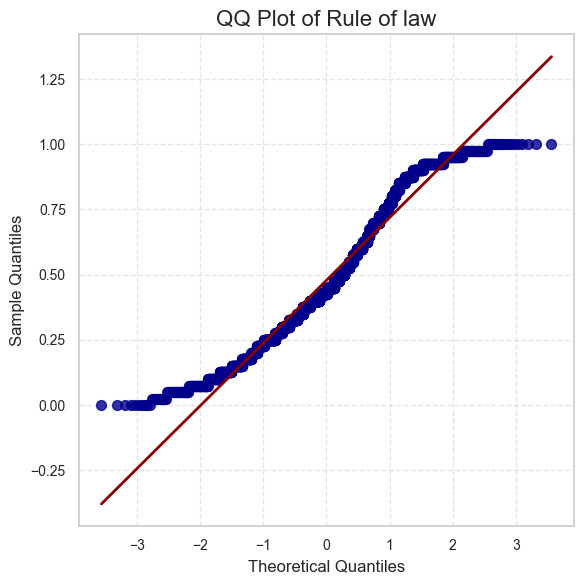

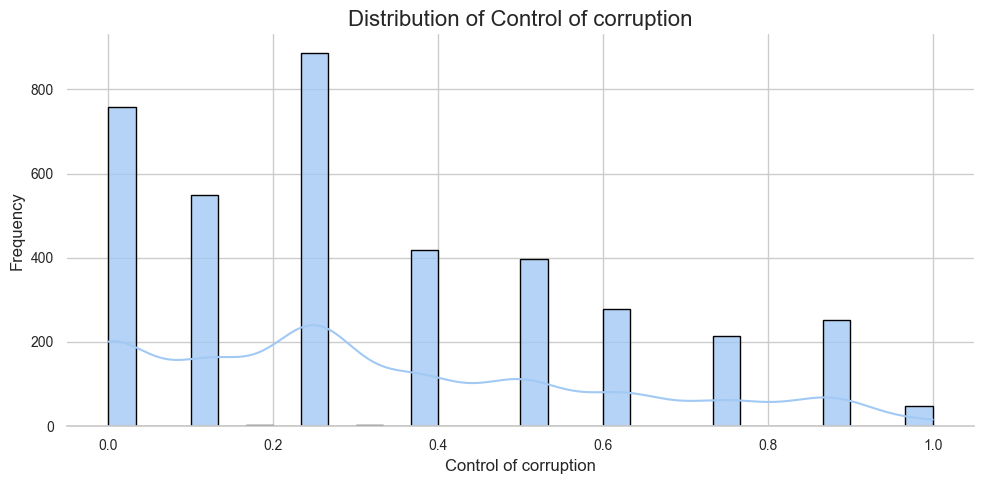

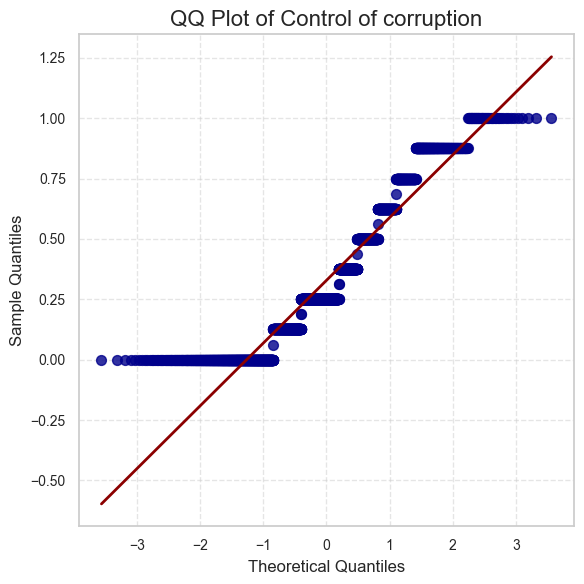

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# --------------------------
# Load data
# --------------------------
df = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\WGI_master_panel_final.xlsx"
)

df.columns = df.columns.str.strip()  # remove extra spaces

# --------------------------
# WGI indicator columns
# --------------------------
wgi_cols = [
    'Voice and Accountability',
    'Political Stability',
    'Government Effectiveness',
    'Regulatory Quality',
    'Rule of law',
    'Control of corruption'
]

# Convert to numeric
for col in wgi_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --------------------------
# Plot styling
# --------------------------
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# --------------------------
# Distribution + QQ Plots
# --------------------------
for col in wgi_cols:
    if df[col].dropna().empty:
        continue

    # ---- Histogram with KDE ----
    plt.figure(figsize=(10, 5))
    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=30,
        edgecolor='black',
        alpha=0.8
    )
    plt.title(f"Distribution of {col.replace('_', ' ')}")
    plt.xlabel(col.replace('_', ' '))
    plt.ylabel("Frequency")
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

    # ---- QQ Plot ----
    plt.figure(figsize=(6, 6))
    res = stats.probplot(df[col].dropna(), dist="norm")

    # Scatter
    plt.scatter(
        res[0][0],
        res[0][1],
        color='darkblue',
        s=50,
        alpha=0.8
    )

    # Reference line
    slope, intercept = res[1][0], res[1][1]
    plt.plot(
        res[0][0],
        slope * res[0][0] + intercept,
        color='darkred',
        lw=2
    )

    plt.title(f"QQ Plot of {col.replace('_', ' ')}")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
